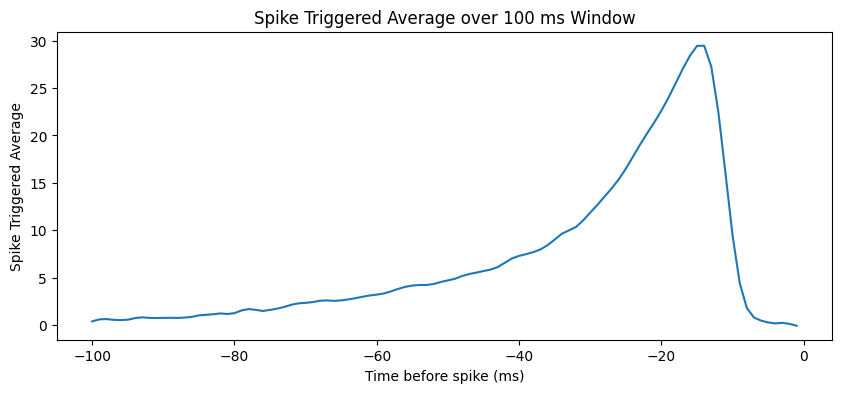

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#load the stimulus and spike train data
stim = np.loadtxt('stim.dat')
rho = np.loadtxt('rho.dat')

#define the time window (100 ms) and the sampling interval (assume 1 ms for simplicity)
window = 100
sampling_interval = 1

#find spike times
spike_times = np.where(rho == 1)[0]

#calculate STA
sta = np.zeros(window)
for t in spike_times:
    if t >= window:
        sta += stim[t-window:t]
sta /= len(spike_times)

#plot STA
plt.figure(figsize=(10, 4))
plt.plot(np.arange(-window, 0), sta)
plt.xlabel('Time before spike (ms)')
plt.ylabel('Spike Triggered Average')
plt.title('Spike Triggered Average over 100 ms Window')
plt.show()


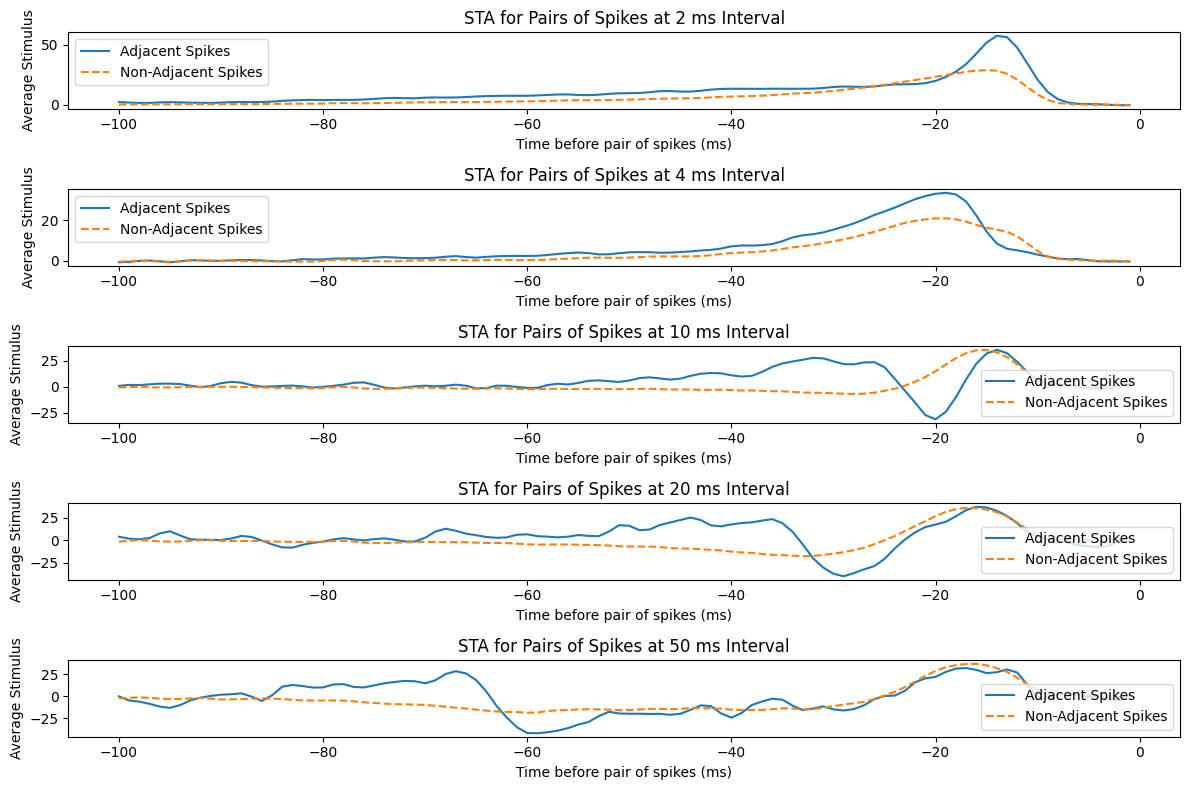

In [ ]:
intervals = [2, 4, 10, 20, 50]
n_intervals = len(intervals)
sta_pairs_adjacent = np.zeros((n_intervals, window))
sta_pairs_nonadjacent = np.zeros((n_intervals, window))

for i, interval in enumerate(intervals):
    pair_times_adjacent = []
    pair_times_nonadjacent = []
    
    #find pairs of spikes for each interval
    for j in range(len(spike_times) - 1):
        if spike_times[j + 1] - spike_times[j] == interval:
            pair_times_adjacent.append(spike_times[j + 1])
        if spike_times[j + 1] - spike_times[j] >= interval:
            pair_times_nonadjacent.append(spike_times[j + 1])
    
    #calculate STA for adjacent pairs
    for t in pair_times_adjacent:
        if t >= window:
            sta_pairs_adjacent[i] += stim[t-window:t]
    sta_pairs_adjacent[i] /= len(pair_times_adjacent) if len(pair_times_adjacent) > 0 else 1
    
    #calculate STA for non-adjacent pairs
    for t in pair_times_nonadjacent:
        if t >= window:
            sta_pairs_nonadjacent[i] += stim[t-window:t]
    sta_pairs_nonadjacent[i] /= len(pair_times_nonadjacent) if len(pair_times_nonadjacent) > 0 else 1

#plot the results
plt.figure(figsize=(12, 8))
for i, interval in enumerate(intervals):
    plt.subplot(n_intervals, 1, i + 1)
    plt.plot(np.arange(-window, 0), sta_pairs_adjacent[i], label='Adjacent Spikes')
    plt.plot(np.arange(-window, 0), sta_pairs_nonadjacent[i], label='Non-Adjacent Spikes', linestyle='--')
    plt.xlabel('Time before pair of spikes (ms)')
    plt.ylabel('Average Stimulus')
    plt.title(f'STA for Pairs of Spikes at {interval} ms Interval')
    plt.legend()
plt.tight_layout()
plt.show()
